# 2 · From Q-learning to a Deep Value Network (1-piece game)

**Q-learning (DDQN, Rainbow)** learns `Q(s, a)` for the 64 placements: the network
has to learn piece geometry, which placements are valid, *and* how good the
resulting board is. With ~1,000 training episodes neither agent learned to play
beyond ~20 placements (report, Section 3).

**Deep Value Network (DVN).** The environment already gives the afterstate `s'ₐ`
(board after placement and line clears) of every valid action, so the agent only
needs a value of boards:

$$a^* = \arg\max_a \; r_a + \gamma \, V_\theta(s'_a)$$

`V` is a small CNN with parallel kernels of several shapes (1×1 to 8×8, plus
full-row 1×8 and full-column 8×1 detectors), trained by TD learning on afterstates.

In [1]:
# `uv sync` installs the project; this line only lets the notebook run without it.
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(4)
%matplotlib inline

In [2]:
from dqn.agent import DDQNAgent1P, RainbowAgent1P
from dvn.agent import load_dvn_agent

ddqn, rainbow = DDQNAgent1P(device="cpu"), RainbowAgent1P(device="cpu")
dvn = load_dvn_agent("../final_weights/dvn_final_20260313_020137.pt")
dvn_cnn = load_dvn_agent("../final_weights/dvn_1P_60avg.pt")

n_params = lambda net: sum(p.numel() for p in net.parameters())
for name, net in [("DDQN (Q-network)", ddqn.policy_net), ("Rainbow (Q-network)", rainbow.policy_net),
                  ("DVN, plain CNN", dvn_cnn.policy_net), ("DVN, multi-kernel", dvn.policy_net)]:
    print(f"{name:22s} {n_params(net):>10,} parameters")

DDQN (Q-network)        2,674,464 parameters
Rainbow (Q-network)     4,755,910 parameters
DVN, plain CNN          1,345,121 parameters
DVN, multi-kernel          54,529 parameters


## Evaluation

The two trained value networks against two baselines, on the same 300 seeded
episodes (100 steps max, as in the report). **Greedy** takes the placement with
the best immediate shaped reward.

In [3]:
from blockblast import BlockBlastEnv
from common.evaluation import run_episodes, print_table
from common.plotting import plot_distributions
from common.policies import RandomPolicy, greedy_1p

policies = {
    "DVN multi-kernel": lambda obs, env: dvn.select_action(obs, epsilon=0.0),
    "DVN plain CNN": lambda obs, env: dvn_cnn.select_action(obs, epsilon=0.0),
    "Greedy": greedy_1p,
    "Random": RandomPolicy(0),
}
results = {name: run_episodes(BlockBlastEnv(punish_for_invalid=-100), pol, 300, seed=0, max_steps=100, progress=False)
           for name, pol in policies.items()}
print_table(results, "BlockBlast 1P, 300 episodes, 100 steps max")


  BlockBlast 1P, 300 episodes, 100 steps max
policy                    n    mean ret     ± sem     median  mean len  ms/dec
------------------------------------------------------------------------------
DVN multi-kernel        300       854.6      30.6      806.8      61.7     0.7
DVN plain CNN           300       657.6      27.7      556.0      52.4     1.5
Greedy                  300       258.8      11.5      235.7      29.6     0.0
Random                  300       -45.3       2.3      -47.3      11.4     0.0


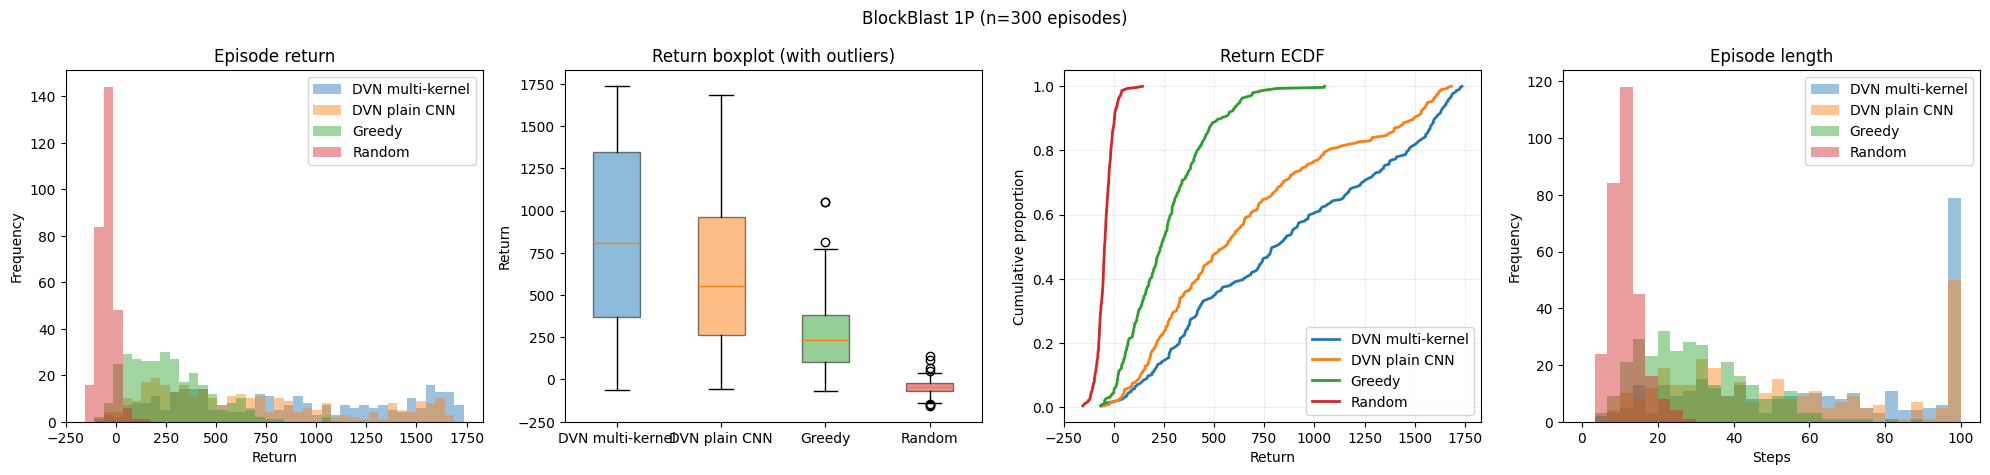

In [4]:
plot_distributions(results, title="BlockBlast 1P");

Returns are heavy-tailed: many short games caused by unlucky piece
sequences, and a few long ones. The median is therefore a more robust summary
than the mean, and the standard error (`± sem`) shows how uncertain the mean is.

## What did the value network learn?

For one position and one piece, each valid placement is coloured by
`r + γ V(s')`, the score the DVN maximises.

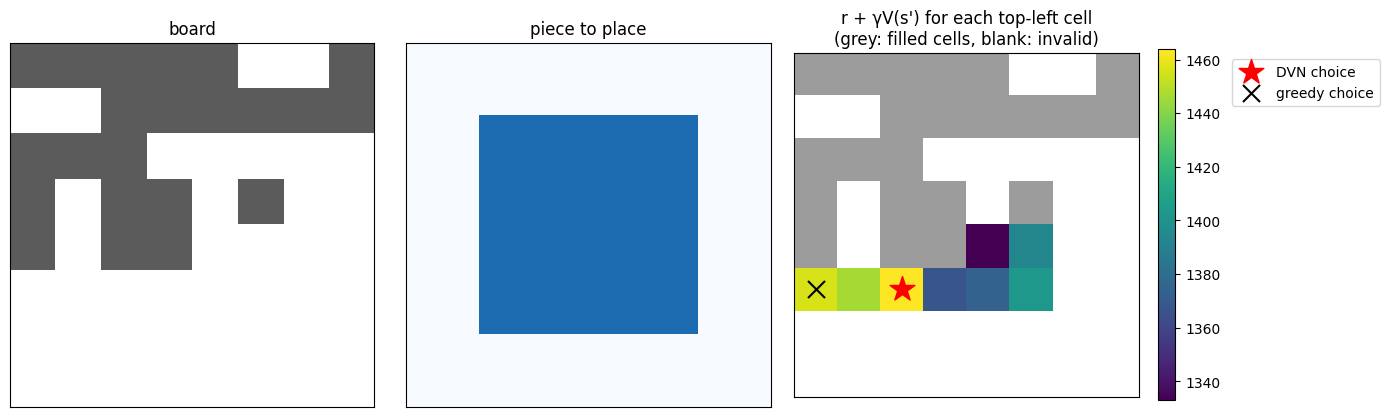

In [5]:
env = BlockBlastEnv(punish_for_invalid=-100)
obs, _ = env.reset(seed=3)
# play with the greedy policy until the board is fairly full and the piece is non-trivial
while obs["board"].sum() < 22 or obs["piece"].sum() < 3:
    obs, _, done, _, _ = env.step(greedy_1p(obs))
    if done:
        obs, _ = env.reset()

valid = obs["valid_placements"].astype(bool)
after, rewards = obs["placements_result"]
with torch.inference_mode():
    v = dvn.policy_net(torch.as_tensor(after.reshape(64, 8, 8), dtype=torch.float32)).numpy().reshape(8, 8)
score = np.where(valid, rewards + dvn.gamma * v, np.nan)
best = np.unravel_index(np.nanargmax(score), score.shape)
greedy = np.unravel_index(np.argmax(np.where(valid, rewards, -np.inf)), score.shape)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
axes[0].imshow(obs["board"], cmap="Greys", vmin=0, vmax=1.4)
axes[0].set_title("board")
piece = obs["piece"][~np.all(obs["piece"] == 0, axis=1)][:, ~np.all(obs["piece"] == 0, axis=0)]
axes[1].imshow(np.pad(piece, 1), cmap="Blues", vmin=0, vmax=1.3)
axes[1].set_title("piece to place")
im = axes[2].imshow(score, cmap="viridis")
axes[2].imshow(np.where(obs["board"] == 1, 1.0, np.nan), cmap="Greys", vmin=0, vmax=1.4, alpha=0.6)
axes[2].scatter(best[1], best[0], marker="*", s=350, c="red", label="DVN choice")
axes[2].scatter(greedy[1], greedy[0], marker="x", s=150, c="black", label="greedy choice")
axes[2].set_title("r + γV(s') for each top-left cell\n(grey: filled cells, blank: invalid)")
axes[2].legend(loc="upper left", bbox_to_anchor=(1.25, 1.0))
plt.colorbar(im, ax=axes[2], fraction=0.046)
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Training the agents

```bash
python -m dqn.train --agent ddqn --episodes 1000
python -m dqn.train --agent rainbow --episodes 1000
python -m dvn.train                 # 10,000 episodes, the configuration of the final run
```

DDQN training curve from the report (return per episode): it does not improve
over 1,000 episodes.

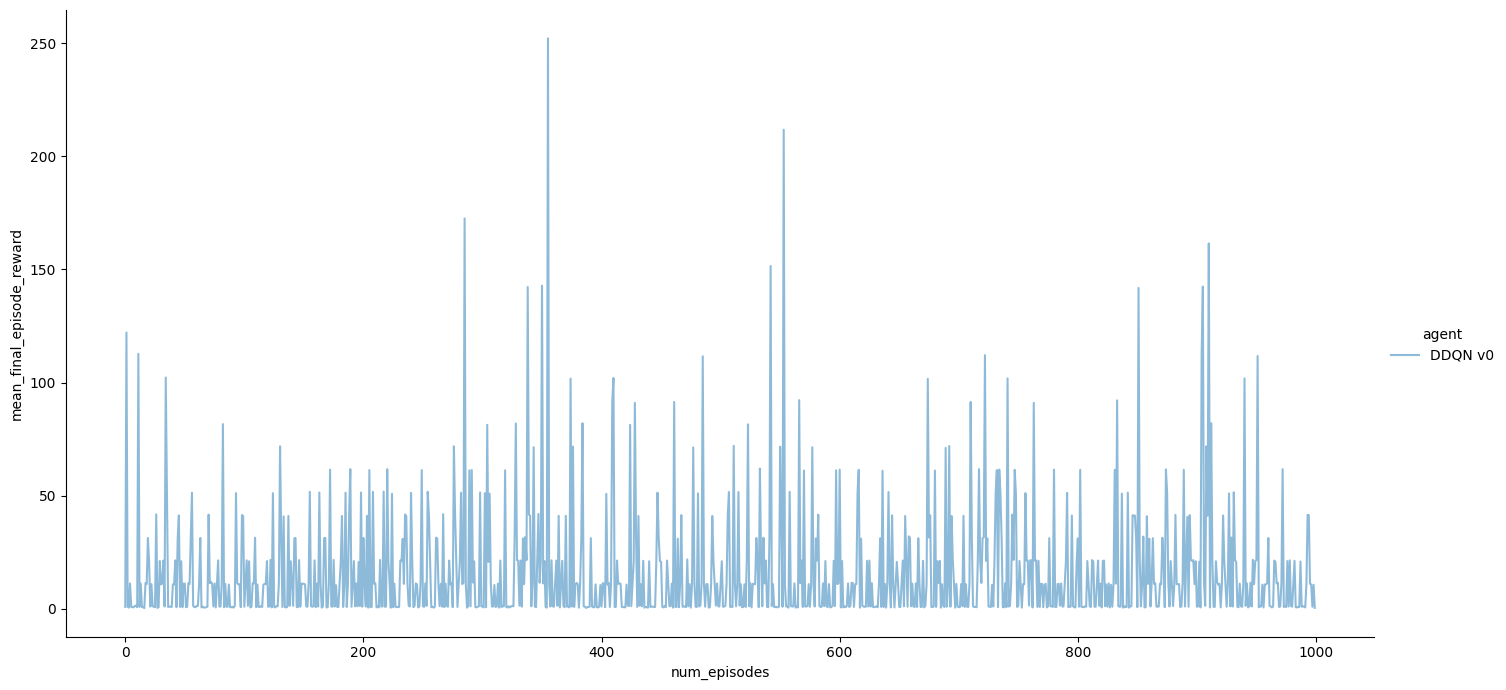

In [6]:
from IPython.display import Image
Image("../report/traindqn.png", width=800)